import libraries for project, intern performance system

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

To load the data

In [3]:
from google.colab import files
uploaded = files.upload()

Saving intern_dataset_realistic (1).csv to intern_dataset_realistic (1).csv


In [4]:
df=pd.read_csv(r"intern_dataset_realistic (1).csv")
df.shape
df.dtypes
df.head(10)

,Intern_ID,Completion_Time,Feedback_Rating,Attendance,Performance_Score
0,INT0001,3.26,4.09,86.50,70.98
1,INT0002,NaN,1.33,59.23,42.16
2,INT0003,5.78,NaN,42.98,49.89
3,INT0004,4.28,1.43,83.16,68.49
4,INT0005,1.53,1.91,74.10,77.51
5,INT0006,2.07,2.46,86.93,97.98
6,INT0007,1.24,1.80,98.06,72.22
7,INT0008,5.86,3.38,55.83,55.62
8,INT0009,4.23,3.05,85.48,79.96
9,INT0010,5.31,2.04,61.52,65.64


Data preprocessing

In [5]:
df.drop(columns=['Intern_ID'], inplace=True)

print("\n Missing values detection\n")
for col in ["Completion_Time","Feedback_Rating","Attendance"]:
    df[col]=df[col].fillna(df[col].median())
print("\n check missing value cleaning!\n",df.isnull().sum())

# features scaling
X=df[["Completion_Time","Feedback_Rating","Attendance"]]
y=df["Performance_Score"]


 Missing values detection


 check missing value cleaning!
 Completion_Time      0
Feedback_Rating      0
Attendance           0
Performance_Score    0
dtype: int64


Feature engineering


In [ ]:
df["Efficiency_index"]= df["Feedback_Rating"]/df["Completion_Time"]


Train_Test_Split section

In [6]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print(f"\n train_size: {X_train.shape[0]}, test_size: {X_test.shape[0]}")


 train_size: 8000, test_size: 2000


model evalution

In [7]:
# random forest implemantation
rf_model=RandomForestRegressor(n_estimators=200,random_state=42)
rf_model.fit(X_train,y_train)
rf_pred=rf_model.predict(X_test)

# xgboost regressor implematation
xgb_model=XGBRegressor(n_estimators=200,random_state=42)
xgb_model.fit(X_train,y_train)
xgb_pred=xgb_model.predict(X_test)

performance evalution

In [8]:
def evaluate(name,y_true,y_pred):
  mae=mean_absolute_error(y_true,y_pred)
  rmse=np.sqrt(mean_squared_error(y_true,y_pred))
  r2=r2_score(y_true,y_pred)
  print(f"\n{name} performance :")
  print(f"MAE: {mae:.3f}")
  print(f"RMSE: {rmse:.3f}")
  print(f"R2_score: {r2:.3f}")
  return mae,rmse,r2

rf_scores = evaluate("Random Forest", y_test, rf_pred)
xgb_scores = evaluate("XGBoost", y_test, xgb_pred)

# 6a. Feature importance (which factor matters most)
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
print("\nFeature Importance (Random Forest):\n", importances.sort_values(ascending=False))











Random Forest performance :
MAE: 7.839
RMSE: 9.810
R2_score: 0.573

XGBoost performance :
MAE: 7.996
RMSE: 10.033
R2_score: 0.554

Feature Importance (Random Forest):
 Completion_Time    0.429213
Feedback_Rating    0.381626
Attendance         0.189160
dtype: float64


classify excellence vs stuggle

In [ ]:
# choosing best_model on basis of R^2 score

In [9]:
best_model= xgb_model if xgb_scores[2] > rf_scores[2] else rf_model
best_name="XGBoost"if best_model is xgb_model else "Random Forest"
print(f"\nBest model selected: {best_name}")

df["Predicted_Score"] = best_model.predict(X)

# Define threshold: top scorers "Excel", bottom scorers "Struggle", rest "Average"
excel_threshold = df["Predicted_Score"].quantile(0.70)
struggle_threshold = df["Predicted_Score"].quantile(0.30)

def classify(score):
    if score >= excel_threshold:
        return "Excel"
    elif score <= struggle_threshold:
        return "Struggle"
    else:
        return "Average"

df["Performance_Category"] = df["Predicted_Score"].apply(classify)

print("\nPerformance Category Counts:\n", df["Performance_Category"].value_counts())




Best model selected: Random Forest

Performance Category Counts:
 Performance_Category
Average     4000
Excel       3000
Struggle    3000
Name: count, dtype: int64


visuallization

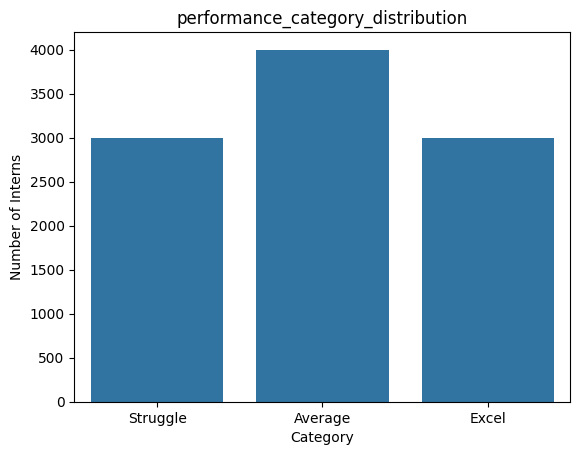

<Figure size 640x480 with 0 Axes>

In [10]:
sns.countplot(data=df, x="Performance_Category", order=["Struggle", "Average", "Excel"])
plt.title("performance_category_distribution")
plt.xlabel("Category")
plt.ylabel("Number of Interns")
plt.show()
plt.savefig("performance_category_distribution.png")



In [11]:
df.to_csv("intern_performance_report_final.csv", index=False)
print("✅ Saved report: intern_performance_report_final.csv")

✅ Saved report: intern_performance_report_final.csv
